In [1]:
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/two_talker_pilot_v01/'
exp_manifest_path = '/om2/user/rphess/Auditory-Attention/'

In [2]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
results = list(Path(result_path).glob('*.csv'))
manifests = list(Path(exp_manifest_path).glob('*pilot_exp.pkl'))

In [10]:
dataframe = []
manifest_path = '/om2/user/rphess/Auditory-Attention/'
for csv_file in results:
    exp_man_path = manifest_path + csv_file.stem + '_exp.pkl'
    exp_results = pd.read_csv(csv_file)
    trials = exp_results[exp_results['trial_type'] == 'dictionary-text']
    trials.reset_index(inplace=True)
    trials = trials.drop(['index', 'Unnamed: 0', 'response_str', 'trial_type', 'internal_node_id', 'stimulus'], axis=1)

    with open(exp_man_path, 'rb') as f:
        exp_manifest = pkl.load(f)
    target_loc = []
    distractor_loc = []
    sex_cond = []
    crossed = []
    azim_delta = []
    elev_delta = []
    distractor_word = []
    for block in exp_manifest.values():
        for trial in block.values():
            target_loc.append(trial['target_loc'])
            distractor_loc.append(trial['distractor_loc'])
            sex_cond.append(trial['sex_cond'])
            crossed.append(trial['crossed'])
            azim_delta.append(trial['azim_delta'])
            elev_delta.append(trial['elev_delta'])
            distractor_word.append(trial['distractor_word'])
    trials['target_loc'] = target_loc
    trials['distractor_loc'] = distractor_loc
    trials['sex_cond'] = sex_cond
    trials['crossed'] = crossed
    trials['azim_delta'] = azim_delta
    trials['elev_delta'] = elev_delta
    trials['distractor_word'] = distractor_word
    trials['part_id'] = csv_file.stem
    dataframe.append(trials)

In [14]:
final_results = pd.concat(dataframe)

In [15]:
final_results['correct'] = final_results['correct'].astype('float64')

In [16]:
import seaborn as sns

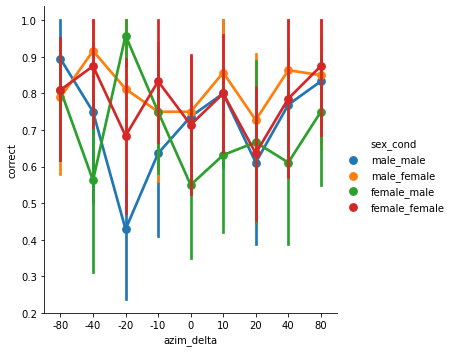

In [17]:
sns.catplot(data=final_results, x='azim_delta', y='correct', kind='point', hue='sex_cond')

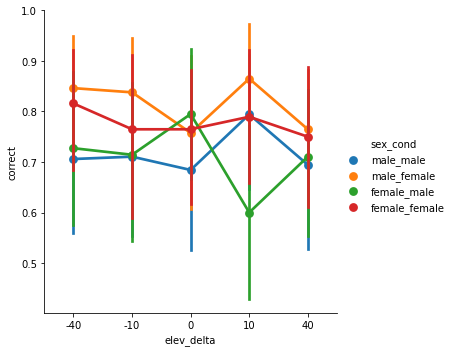

In [18]:
sns.catplot(data=final_results, x='elev_delta', y='correct', kind='point', hue='sex_cond')

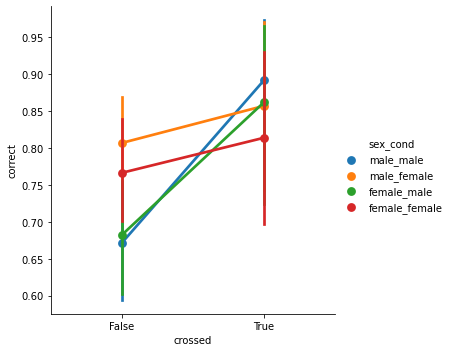

In [19]:
sns.catplot(data=final_results, x='crossed', y='correct', kind='point', hue='sex_cond')